# Progetto di esempio - Che mezzo usa per venire a scuola?

B.6 - Data science e Machine Learning: dai dati ai modelli

Progetto di esempio svolto sul dataset simulato dei tragitti casa-scuola (`tragitti_esempio.csv`, 153 risposte). Mostra la struttura attesa e il livello di dettaglio dei commenti.

## 1. Domanda

- Domanda: dalla distanza casa-scuola e dal tempo impiegato si può prevedere il mezzo di trasporto principale?
- Tipo di problema: classificazione a sei classi (piedi, bici, monopattino, bus, auto, treno)
- Etichetta: `mezzo`; caratteristiche: `distanza_km`, `tempo_min`, `fascia_partenza`, `anno_corso`
- Uso possibile: stimare l'uso dei mezzi in una scuola in cui si conoscono solo distanze e tempi (per esempio da un'indagine precedente), come supporto a una proposta sugli orari degli ingressi. Il modello non deve servire a decisioni sui singoli studenti.

## 2. Dati

- Fonte: questionario anonimo sui tragitti (qui: dati simulati forniti con il corso)
- Licenza: materiale del corso
- Unità di osservazione: uno studente, in un giorno tipico
- 153 righe, 7 colonne
- Possibili distorsioni: rispondono solo alcune classi; il giorno della raccolta può non essere tipico; i mezzi poco usati (treno) hanno pochi esempi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dati = pd.read_csv("tragitti_esempio.csv")
print(dati.shape)
dati.head()

(153, 7)


,id,inviato_il,anno_corso,mezzo,distanza_km,tempo_min,fascia_partenza
0,1,2026-10-06 08:50:44,4,bus,10.0,46,7:00-7:30
1,2,2026-10-06 08:10:32,5,auto,8.6,27,7:00-7:30
2,3,2026-10-06 08:05:40,5,bicicletta,4.7,19,7:30-7:45
3,4,2026-10-06 08:39:44,4,monopattino elettrico,3.7,20,dopo le 7:45
4,5,2026-10-06 08:55:09,3,piedi,0.8,11,dopo le 7:45


## 3. Pulizia

Stesse operazioni di L5, raccolte in una funzione.

In [2]:
def pulisci(d):
    d = d.copy()
    d["mezzo"] = d["mezzo"].str.strip().str.lower().replace({
        "autobus": "bus", "pullman": "bus", "a piedi": "piedi", "bicicletta": "bici",
        "macchina": "auto", "in auto": "auto", "monopattino elettrico": "monopattino", "treno + bus": "treno"})
    d["distanza_km"] = pd.to_numeric(d["distanza_km"].astype(str).str.replace(",", "."), errors="coerce")
    d["tempo_min"] = pd.to_numeric(d["tempo_min"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
    d = d.drop_duplicates(subset=["anno_corso", "mezzo", "distanza_km", "tempo_min", "fascia_partenza"])
    d.loc[(d["distanza_km"] <= 0) | (d["distanza_km"] > 100), "distanza_km"] = np.nan
    d.loc[(d["tempo_min"] <= 0) | (d["tempo_min"] > 150), "tempo_min"] = np.nan
    return d.drop(columns=["inviato_il"]).dropna(subset=["distanza_km", "tempo_min", "fascia_partenza"])

pulito = pulisci(dati)
print(pulito.shape)
pulito["mezzo"].value_counts()

(139, 6)


mezzo
bus            48
auto           26
piedi          24
bici           17
monopattino    15
treno           9
Name: count, dtype: int64

| operazione | righe o valori coinvolti | motivazione |
|---|---|---|
| mezzo uniformato | 23 varianti ridotte a 6 | coerenza |
| distanza e tempo convertiti | 21 e 10 valori | formato |
| duplicati | 3 righe | invii ripetuti |
| valori impossibili o anomali errati | 4 valori | regole del dizionario |
| righe incomplete eliminate | 11 righe | il modello richiede righe complete |

## 4. Esplorazione

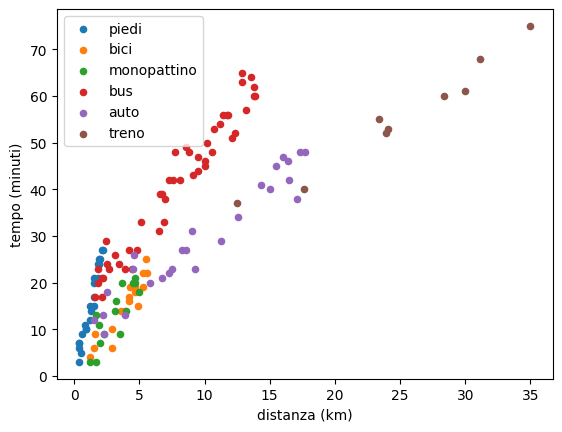

In [3]:
MEZZI = ["piedi", "bici", "monopattino", "bus", "auto", "treno"]
for i, m in enumerate(MEZZI):
    d = pulito[pulito["mezzo"] == m]
    plt.scatter(d["distanza_km"], d["tempo_min"], s=20, label=m, color=f"C{i}")
plt.xlabel("distanza (km)"); plt.ylabel("tempo (minuti)"); plt.legend()
plt.show()

Commento: il tempo cresce con la distanza, con pendenze diverse per mezzo. Sulle brevi distanze (sotto 5 km) piedi, bici e monopattino si sovrappongono molto: saranno le classi più difficili. Il treno si distingue per distanze sopra i 20 km.

In [4]:
pulito["velocita_kmh"] = pulito["distanza_km"] / (pulito["tempo_min"] / 60)
pulito.groupby("mezzo")["velocita_kmh"].median().reindex(MEZZI).round(1)

mezzo
piedi           4.8
bici           15.4
monopattino    14.1
bus            11.5
auto           19.7
treno          27.4
Name: velocita_kmh, dtype: float64

Commento: la velocità media (distanza diviso tempo) separa meglio i mezzi lenti (piedi, circa 5 km/h) da bici e monopattino. Si aggiunge come caratteristica: è calcolata dalle stesse informazioni, quindi non introduce una fuga di informazione.

In [5]:
pd.crosstab(pulito["fascia_partenza"], pulito["mezzo"])[MEZZI]

mezzo,piedi,bici,monopattino,bus,auto,treno
fascia_partenza,,,,,,
7:00-7:30,1,1,0,21,9,2
7:30-7:45,10,10,7,9,9,2
dopo le 7:45,13,6,8,8,5,0
prima delle 7:00,0,0,0,10,3,5


Commento: chi parte prima delle 7:00 usa quasi solo bus, treno o auto: la fascia di partenza dipende dal tempo di tragitto e porta poca informazione nuova.

## 5. Modelli

In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

X = pulito[["distanza_km", "tempo_min", "velocita_kmh"]]
y = pulito["mezzo"]
X_add, X_ver, y_add, y_ver = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
print("addestramento", len(X_add), " verifica", len(X_ver))

base = DummyClassifier(strategy="most_frequent")
print("baseline (validazione incrociata):", round(cross_val_score(base, X_add, y_add, cv=5).mean(), 3))

addestramento 104  verifica 35
baseline (validazione incrociata): 0.346


In [7]:
risultati = {}
for p in [2, 3, 4, 5, 6]:
    risultati[f"albero prof. {p}"] = cross_val_score(DecisionTreeClassifier(max_depth=p, random_state=0), X_add, y_add, cv=5).mean()

scala = StandardScaler().fit(X_add)
X_add_std = scala.transform(X_add)
for k in [1, 3, 5, 9]:
    risultati[f"k-NN k={k}"] = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_add_std, y_add, cv=5).mean()

pd.Series(risultati).round(3).sort_values(ascending=False)

k-NN k=5          0.741
k-NN k=9          0.740
k-NN k=3          0.730
k-NN k=1          0.711
albero prof. 4    0.702
albero prof. 3    0.694
albero prof. 5    0.693
albero prof. 6    0.672
albero prof. 2    0.606
dtype: float64

Commento: k-NN e alberi superano nettamente la baseline (circa 0,70-0,74 contro 0,35). Si sceglie il modello con la media più alta. Le differenze tra i migliori (0,70-0,74) sono dell'ordine della variabilità della validazione incrociata: se contasse poter spiegare le decisioni, l'albero di profondità 4 sarebbe una scelta altrettanto ragionevole. La standardizzazione per il k-NN è calcolata solo sui dati di addestramento.

## 6. Valutazione finale e analisi degli errori

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

migliore = max(risultati, key=risultati.get)
if migliore.startswith("k-NN"):
    k = int(migliore.split("=")[1])
    modello = KNeighborsClassifier(n_neighbors=k).fit(X_add_std, y_add)
    previsti = modello.predict(scala.transform(X_ver))       # stessa scala dell'addestramento
else:
    profondita = int(migliore.split()[-1])
    modello = DecisionTreeClassifier(max_depth=profondita, random_state=0).fit(X_add, y_add)
    previsti = modello.predict(X_ver)
print("modello scelto:", migliore)
print("accuratezza sulla verifica:", round((previsti == y_ver).mean(), 3),
      " baseline:", round((y_ver == y_add.mode()[0]).mean(), 3))
pd.DataFrame(confusion_matrix(y_ver, previsti, labels=MEZZI), index=MEZZI, columns=MEZZI)

modello scelto: k-NN k=5
accuratezza sulla verifica: 0.771  baseline: 0.343


,piedi,bici,monopattino,bus,auto,treno
piedi,6,0,0,0,0,0
bici,0,4,0,0,0,0
monopattino,0,3,0,0,1,0
bus,1,0,0,11,0,0
auto,0,1,1,1,4,0
treno,0,0,0,0,0,2


In [9]:
print(classification_report(y_ver, previsti, zero_division=0))

              precision    recall  f1-score   support

        auto       0.80      0.57      0.67         7
        bici       0.50      1.00      0.67         4
         bus       0.92      0.92      0.92        12
 monopattino       0.00      0.00      0.00         4
       piedi       0.86      1.00      0.92         6
       treno       1.00      1.00      1.00         2

    accuracy                           0.77        35
   macro avg       0.68      0.75      0.70        35
weighted avg       0.74      0.77      0.74        35



Commento: gli errori si concentrano tra mezzi con velocità simili sulle brevi distanze: nessuno dei 4 monopattini di verifica è riconosciuto, 3 vengono scambiati per bici (velocità mediane 14 e 15 km/h). Con queste caratteristiche i due mezzi non sono distinguibili: servirebbe un'altra informazione, oppure unire le due classi. Il treno ha pochissimi esempi di verifica: il suo risultato è poco affidabile. Con pochi dati per classe il risultato varierebbe con una suddivisione diversa.

## 7. Limiti

- dati simulati; con dati reali le relazioni saranno meno regolari
- pochi esempi per alcuni mezzi (treno, monopattino)
- "mezzo principale" è una semplificazione: molti tragitti combinano più mezzi
- il modello non va usato per trarre conclusioni sui singoli studenti

## 8. Conclusioni

Distanza e tempo permettono di riconoscere il mezzo principale nella maggior parte dei casi, molto meglio che indovinando il mezzo più comune. Aggiungere la velocità media migliora leggermente il risultato (con il k-NN, da 0,71 a 0,74 in validazione incrociata). Il modello confonde i mezzi lenti sulle brevi distanze e ha bisogno di più dati per i mezzi poco usati.